# מטלת סיום – חלק 2 | Movie Rating Prediction

**שמות חברי הצוות + ת.ז.:** <FILL IN>

**קישור ל-GitHub:** <FILL IN>

In [1]:
# ============================================================
#  מטלת סיום – חלק 2 | Movie Rating Prediction
#  Chen Hajaj · Ariel University · Machine Learning
# ============================================================
# שמות חברי הצוות + ת.ז.:  <FILL IN>
# קישור ל-GitHub:            <FILL IN>
# ============================================================

##  ייבוא ספריות

In [1]:
import re
import ast
import bisect
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
import joblib
import matplotlib.patches as mpatches


from sklearn.linear_model    import ElasticNet
from sklearn.ensemble        import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from sklearn.impute          import SimpleImputer
from sklearn.compose         import ColumnTransformer
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base            import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV
from IPython.display         import display_html
from IPython.display         import display, HTML

In [2]:
def style_table(df, title=None, highlight_col=None, higher_is_better=True):
    styled = df.style\
        .set_table_styles([
            {'selector': 'thead th',
             'props': [('background-color', '#2c3e50'),
                       ('color', 'white'),
                       ('font-weight', 'bold'),
                       ('text-align', 'center'),
                       ('padding', '8px 14px'),
                       ('letter-spacing', '0.5px')]},
            {'selector': 'tbody tr:nth-child(even)',
             'props': [('background-color', '#f5f6fa')]},
            {'selector': 'tbody tr:hover',
             'props': [('background-color', '#eaf0fb')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 14px')]},
        ])\
        .set_table_attributes(
            'style="border-collapse: collapse; font-family: sans-serif; font-size: 13px;"')

    if title:
        styled = styled.set_caption(title)\
            .set_table_styles([{'selector': 'caption',
                                'props': [('font-size', '14px'),
                                          ('font-weight', 'bold'),
                                          ('color', '#2c3e50'),
                                          ('padding-bottom', '8px')]}], overwrite=False)

    if highlight_col and highlight_col in df.columns:
        best_color  = '#d5e8d4'
        worst_color = '#f8cecc'
        if higher_is_better:
            styled = styled.highlight_max(subset=[highlight_col], color=best_color)
            styled = styled.highlight_min(subset=[highlight_col], color=worst_color)
        else:
            styled = styled.highlight_min(subset=[highlight_col], color=best_color)
            styled = styled.highlight_max(subset=[highlight_col], color=worst_color)

    return styled

## טעינת הדאטה

In [3]:
dataset = pd.read_csv("dataset.csv", na_values=['\\N', 'N/A', 'null'], low_memory=False)
# טעינת קובץ של הבמאים 
df_crew = pd.read_csv("title.crew.tsv.gz", sep='\t', usecols=['tconst', 'directors'], low_memory=False)
# מיזוג של הקבצים לדאטה שכוללת את הבמאים 
dataset = pd.merge(dataset, df_crew, on='tconst', how='left')

## בניית פונקציות עזר לניקוי הנתונים 


In [4]:
# פונקציות ניקוי 
def _clean_year(val):
    if pd.isna(val):
        return np.nan
    try:
        year = int(float(val))
        if re.fullmatch(r'\d{4}', str(year)):
            return year
        return np.nan
    except (ValueError, TypeError):
        return np.nan 
 
def _clean_runtime(val):
    # רק מספר ולא טקסט
    if pd.isna(val):
        return np.nan
    try:
        return float(val)
    except (ValueError, TypeError):
        return np.nan
 
def _clean_rating(val):
    # ערך תקין בין 1.0-10.0
    if pd.isna(val):
        return np.nan
    try:
        r = float(val)
        return r if 1.0 <= r <= 10.0 else np.nan
    except (ValueError, TypeError):
        return np.nan
 
 
def _clean_genres(val):
    # מחזיר רשימת זאנרים נקייה
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|\[\])$', s, re.IGNORECASE):
        return []
    try:
        parsed = ast.literal_eval(s)
        items  = [str(g).strip() for g in parsed] \
                 if isinstance(parsed, list) else [str(parsed).strip()]
    except (ValueError, SyntaxError):
        items = re.split(r'[,|;]', s)
    cleaned = []
    for item in items:
        g = item.strip().title()
        if g and re.match(r'^[A-Za-z\- ]{2,30}$', g):
            if not re.match(r'^(N/A|\\N|Nan|None|Na)$', g, re.IGNORECASE):
                cleaned.append(g)
    return cleaned
  
def _clean_actors(val):
    # בודק שהשחקן באמת עומד בקריטריונים עם התחלה של nm
    if pd.isna(val):
        return []
    s = str(val).strip()
    if re.match(r'^(\\N|\[\]|N/A)$', s, re.IGNORECASE):
        return []
    return re.findall(r'nm\d{7,8}', s)
 
 
def _clean_director(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if re.match(r'^(\\N|N/A|NA|nan|none)$', s, re.IGNORECASE):
        return np.nan
    matches = re.findall(r'nm\d{7,8}', s)
    if not matches:
        return np.nan
    return ','.join(matches)

## Feature Engineering


In [5]:
def _safe_list(val):
    if isinstance(val, list): return val
    if pd.isna(val): return []
    try:
        parsed = ast.literal_eval(str(val))
        return parsed if isinstance(parsed, list) else [parsed]
    except Exception:
        return [x.strip() for x in str(val).split(',') if x.strip()]

def add_static_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['num_genres']  = df['genres'].apply(lambda g: len(_safe_list(g)))
    df['is_too_short'] = (df['runtimeMinutes'] < 75).astype(float)
    df['is_too_long']  = (df['runtimeMinutes'] > 150).astype(float)
    return df
    
## חישוב היחס בין אורך הסרט לחציון הסרטים עפי גאנר - רק סרטים של שנה קטנה מהשנה הנוכחית  
class RelativeRuntimeTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X[['genres', 'startYear', 'runtimeMinutes']].copy()
        
        # חילוץ הז'אנר הראשון
        df['_first_genre'] = df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')
        
        # מסננים שורות חסרות וממיינים לפי שנה פעם אחת מראש
        df = df.dropna(subset=['startYear', 'runtimeMinutes']).sort_values('startYear')
        
        # בניית מילון ששומר לכל ז'אנר את השנים ואורכי הסרטים כמערכים מהירים
        self.genre_history_ = {}
        for genre, group in df.groupby('_first_genre'):
            self.genre_history_[genre] = {
                'years': group['startYear'].values,
                'runtimes': group['runtimeMinutes'].values}
            
        return self

    def transform(self, X):
        X = X.copy()
        X['_first_genre'] = X['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')
        
        def calc(row):
            genre = row['_first_genre']
            current_year = row['startYear']
            
            # אם אין היסטוריה לז'אנר או שהשנה חסרה
            if genre not in self.genre_history_ or pd.isna(current_year):
                return np.nan
                
            # חיפוש בינארי מהיר למציאת נקודת החיתוך (אינדקס) של כל השנים שקטנות מהשנה הנוכחית
            years_array = self.genre_history_[genre]['years']
            idx = bisect.bisect_left(years_array, current_year)
            
            # אם האינדקס הוא 0, זה אומר שאין סרטים קודמים בז'אנר הזה
            if idx == 0:
                return np.nan
                
            # חותכים את מערך אורכי הסרטים עד לאינדקס ומחשבים חציון
            past_runtimes = self.genre_history_[genre]['runtimes'][:idx]
            median = np.median(past_runtimes)
            
            if pd.isna(median) or median == 0:
                return np.nan
                
            return row['runtimeMinutes'] / median

        X['relative_runtime_by_genre'] = X.apply(calc, axis=1)
        return X.drop(columns=['_first_genre'])
        
##חישוב כמה פעמים שחקני הסרט שיחקו בעבר 
class ActorExpTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        df = X[['lead_actors_ids', 'startYear']].dropna().copy()
        df['lead_actors_ids'] = df['lead_actors_ids'].apply(lambda x: _safe_list(x))
        df = df.explode('lead_actors_ids').sort_values('startYear')
        self.actor_years_ = df.groupby('lead_actors_ids')['startYear'].apply(list).to_dict()
        return self

    def transform(self, X):
        X = X.copy()
        def calc(row):
            actors = _safe_list(row['lead_actors_ids'])
            year = row['startYear']
            # מחזיר גם את חווית העבר וגם האם השחקן חדש
            if not actors or pd.isna(year):
                return pd.Series({'avg_actors_past_experience': 0.0, 'is_new_actors': 1.0})
            exp = [bisect.bisect_left(self.actor_years_.get(a, []), year) for a in actors]
            avg_exp = float(np.mean(exp))
            is_new = 1.0 if avg_exp == 0 else 0.0
            return pd.Series({'avg_actors_past_experience': avg_exp, 'is_new_actors': is_new})
            
        new_cols = X.apply(calc, axis=1)
        X = pd.concat([X, new_cols], axis=1)
        return X
        
class DirectorAvgTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        # 1. הכנת נתונים עבור ברירות המחדל (Cold Start) - ללא כפילויות של במאים
        orig_df = X[['genres', 'startYear']].copy()
        orig_df['averageRating'] = y
        orig_df['_first_genre'] = orig_df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')
        orig_df = orig_df.dropna(subset=['startYear', 'averageRating']).sort_values('startYear')

        # נשמור היסטוריה כללית לחישוב ממוצע גלובלי וממוצע ז'אנר רץ 
        self.global_years_ = orig_df['startYear'].values
        self.global_ratings_ = orig_df['averageRating'].values

        self.genre_history_ = {}
        for g, group in orig_df.groupby('_first_genre'):
            self.genre_history_[g] = {
                'years': group['startYear'].values,
                'ratings': group['averageRating'].values }

        #  הכנת נתוני ההיסטוריה לכל במאי 
        df = X[['directors', 'genres', 'startYear']].copy()
        df['averageRating'] = y
        df['_first_genre'] = df['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')
        df['directors'] = df['directors'].apply(lambda x: _safe_list(x))
        df = df.explode('directors').dropna(subset=['directors', 'startYear', 'averageRating']).sort_values('startYear')

        self.dir_history_ = {}
        for d, group in df.groupby('directors'):
            self.dir_history_[d] = {
                'years': group['startYear'].values,
                'ratings': group['averageRating'].values,
                'genres': group['_first_genre'].values}

        return self

    def transform(self, X):
        X = X.copy()
        X['_first_genre'] = X['genres'].apply(
            lambda g: _safe_list(g)[0] if _safe_list(g) else 'Unknown')

        def calc(row):
            year = row['startYear']
            genre = row['_first_genre']
            current_directors = _safe_list(row['directors'])

            # במקרה קיצון של שנה חסרה, נחזיר ערכים ריקים כברירת מחדל
            if pd.isna(year):
                return pd.Series({
                    'director_past_avg': np.nan, 'is_new_director': 1.0,
                    'director_genre_past_avg': np.nan, 'director_genre_count': 0.0,
                    'is_new_director_genre': 1.0})

            #  חישוב ברירות מחדל עד לאותה שנה בלבד 
            idx_global = bisect.bisect_left(self.global_years_, year)
            global_past_avg = np.mean(self.global_ratings_[:idx_global]) if idx_global > 0 else np.nan

            genre_past_avg = global_past_avg 
            if genre in self.genre_history_:
                idx_genre = bisect.bisect_left(self.genre_history_[genre]['years'], year)
                if idx_genre > 0:
                    genre_past_avg = np.mean(self.genre_history_[genre]['ratings'][:idx_genre])

            #  איסוף היסטוריה לבמאים הנוכחיים 
            dir_past_ratings = []
            dir_genre_past_ratings = []

            for d in current_directors:
                if d in self.dir_history_:
                    idx_d = bisect.bisect_left(self.dir_history_[d]['years'], year)
                    if idx_d > 0:
                        # שולפים רק דירוגים וז'אנרים משנים קודמות
                        past_ratings = self.dir_history_[d]['ratings'][:idx_d]
                        past_genres = self.dir_history_[d]['genres'][:idx_d]
                        
                        dir_past_ratings.extend(past_ratings)
                        
                        # מסננים רק את הסרטים שתואמים לז'אנר הנוכחי
                        mask = (past_genres == genre)
                        dir_genre_past_ratings.extend(past_ratings[mask])

            #  הרכבת התוצאה הסופית  
            if dir_past_ratings:
                res_dir_avg = np.mean(dir_past_ratings)
                res_is_new_dir = 0.0
            else:
                res_dir_avg = global_past_avg
                res_is_new_dir = 1.0

            if dir_genre_past_ratings:
                res_dir_genre_avg = np.mean(dir_genre_past_ratings)
                res_dir_genre_count = float(len(dir_genre_past_ratings))
                res_is_new_dir_genre = 0.0
            else:
                res_dir_genre_avg = genre_past_avg
                res_dir_genre_count = 0.0
                res_is_new_dir_genre = 1.0

            return pd.Series({
                'director_past_avg': res_dir_avg,
                'is_new_director': res_is_new_dir,
                'director_genre_past_avg': res_dir_genre_avg,
                'director_genre_count': res_dir_genre_count,
                'is_new_director_genre': res_is_new_dir_genre})

        # הפעלת הפונקציה ליצירת כל העמודות החדשות ושילובן בדאטה
        new_cols = X.apply(calc, axis=1)
        X = pd.concat([X, new_cols], axis=1)

        return X.drop(columns=['_first_genre'])

## prepare_data

In [6]:
def prepare_data(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # אם directors לא קיים — מנסים לטעון מקובץ הצוות
    if 'directors' not in df.columns:
        try:
            _crew = pd.read_csv("title.crew.tsv.gz", sep='\t',
                                usecols=['tconst', 'directors'], low_memory=False)
            df = pd.merge(df, _crew, on='tconst', how='left')
        # אם הקובץ לא קיים — עמודה ריקה
        except Exception:
            df['directors'] = np.nan
    # מימוש פונקציות העזר של הניקוי
    df['startYear']       = df['startYear'].apply(_clean_year)
    df['runtimeMinutes']  = df['runtimeMinutes'].apply(_clean_runtime)
    df['genres']          = df['genres'].apply(_clean_genres)
    df['lead_actors_ids'] = df['lead_actors_ids'].apply(_clean_actors)
    df['directors']       = df['directors'].apply(_clean_director)

    # הוספת הפיצ'רים הפשוטים
    df = add_static_features(df)

    #   ניקוי שורות ריקות לפני חישוב ההיסטוריה 
    if 'averageRating' in df.columns:
        df['averageRating'] = df['averageRating'].apply(_clean_rating)
        df = df.dropna(subset=['averageRating', 'startYear']).reset_index(drop=True)
    else:
        # דאטת בדיקה — אין דירוג, רק מנקה שורות בלי שנה
        df = df.dropna(subset=['startYear']).reset_index(drop=True)

    # הסרת עמודות לא רלוונטיות
    COLS_TO_DROP = ['numVotes', 'BoxOffice', 'plot', 'Language', 'Country', 'budget']
    df = df.drop(columns=[c for c in COLS_TO_DROP if c in df.columns])

    return df

## הכנת דאטת האימון



In [7]:
dataset_clean = prepare_data(dataset.copy())
dataset_clean = dataset_clean.dropna(subset=['averageRating']).reset_index(drop=True)

_raw = dataset.copy()
_raw['averageRating'] = _raw['averageRating'].apply(_clean_rating)
_raw['startYear']     = _raw['startYear'].apply(_clean_year)
_raw['genres']        = _raw['genres'].apply(_clean_genres)
_raw = _raw.dropna(subset=['averageRating', 'startYear']).sort_values('startYear').reset_index(drop=True)
meta_df = _raw[['primaryTitle', 'startYear', 'genres', 'directors']].copy()

y = dataset_clean['averageRating'].values
X = dataset_clean.drop(columns=['averageRating'])

# הגדרת Pipeline ומודלים

In [ ]:
# רשימת הפיצ'רים המספריים הסופיים 
FEATURE_COLS = [
    'startYear', 'num_genres', 'is_too_short', 'is_too_long',
    'relative_runtime_by_genre', 'director_past_avg', 'avg_actors_past_experience', 'director_genre_past_avg', 'director_genre_count']
feature_engineering_pipeline = Pipeline(steps=[
    ('relative_runtime', RelativeRuntimeTransformer()),
    ('actor_exp', ActorExpTransformer()),
    ('director_avg', DirectorAvgTransformer())])
# הגדרת ה-Preprocessor 
preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())]), FEATURE_COLS)], remainder='drop')

# הגדרת רשתות פרמטרים 
param_grid_en = {
    'alpha':    [0.001, 0.01, 0.1],
    'l1_ratio': [0.2, 0.5, 0.8],}

param_grid_rf = {
    'max_depth':        [6, 10, 15],
    'min_samples_leaf': [10, 20, 40],}

# ה-Pipelines הסופיים והמוגנים מ-Data Leakage
pipeline_en = Pipeline(steps=[
    ('feature_eng', feature_engineering_pipeline),
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        ElasticNet(max_iter=2000, random_state=42),
        param_grid_en, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )),
])

pipeline_rf = Pipeline(steps=[
    ('feature_eng', feature_engineering_pipeline), 
    ('preprocessor', preprocessor),
    ('model', GridSearchCV(
        RandomForestRegressor(n_estimators=60, random_state=42, n_jobs=-1),
        param_grid_rf, cv=3, scoring='neg_mean_squared_error', n_jobs=-1
    )),
])

## הרצת CV

In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

def run_stability_cv(pipeline, X, y, model_name):
    fold_metrics = []
    oof_preds = np.zeros(len(y))

    for fold_num, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx],      y[test_idx]

        pipeline.fit(X_train, y_train)
        preds_test = pipeline.predict(X_test)
        oof_preds[test_idx] = preds_test

        fold_metrics.append({
            'fold': fold_num + 1,
            'r2':   r2_score(y_test, preds_test),
            'rmse': np.sqrt(mean_squared_error(y_test, preds_test)),
            'mae':  mean_absolute_error(y_test, preds_test),
        })

    metrics_df = pd.DataFrame(fold_metrics)
    r2   = metrics_df['r2'].mean();   r2_s  = metrics_df['r2'].std()
    rmse = metrics_df['rmse'].mean(); rmse_s = metrics_df['rmse'].std()
    mae  = metrics_df['mae'].mean();  mae_s  = metrics_df['mae'].std()

    display(HTML(f"""
        <div style="margin:16px 0; padding:14px 20px; border-left:5px solid #2c3e50;
                    background:#f5f6fa; font-family:sans-serif; border-radius:4px;">
            <div style="font-size:15px; font-weight:bold; color:#2c3e50; margin-bottom:8px;">
                {model_name}
            </div>
            <table style="border-collapse:collapse; font-size:13px;">
                <tr>
                    <td style="padding:3px 16px 3px 0; color:#555;">R²</td>
                    <td style="font-weight:bold; color:#2c3e50;">{r2:.4f}</td>
                    <td style="color:#888; padding-left:8px;">± {r2_s:.4f}</td>
                </tr>
                <tr>
                    <td style="padding:3px 16px 3px 0; color:#555;">RMSE</td>
                    <td style="font-weight:bold; color:#2c3e50;">{rmse:.4f}</td>
                    <td style="color:#888; padding-left:8px;">± {rmse_s:.4f}</td>
                </tr>
                <tr>
                    <td style="padding:3px 16px 3px 0; color:#555;">MAE</td>
                    <td style="font-weight:bold; color:#2c3e50;">{mae:.4f}</td>
                    <td style="color:#888; padding-left:8px;">± {mae_s:.4f}</td>
                </tr>
            </table>
        </div>
    """))

    return oof_preds, metrics_df

# הרצה בפועל
oof_en, stability_en = run_stability_cv(pipeline_en, X, y, 'Elastic Net')
oof_rf, stability_rf = run_stability_cv(pipeline_rf, X, y, 'Random Forest')

# טבלת השוואה סופית
comparison_df = pd.DataFrame({
    'Model':      ['Elastic Net', 'Random Forest'],
    'R² (mean)':  [stability_en['r2'].mean(),   stability_rf['r2'].mean()],
    'RMSE (mean)':[stability_en['rmse'].mean(),  stability_rf['rmse'].mean()],
    'MAE (mean)': [stability_en['mae'].mean(),   stability_rf['mae'].mean()],
    'RMSE (std)': [stability_en['rmse'].std(),   stability_rf['rmse'].std()],
}).round(4)

display(HTML("""
    <div style="margin:20px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            השוואת מודלים
        </span>
    </div>
"""))
display(style_table(comparison_df, highlight_col='RMSE (mean)', higher_is_better=False))

## ניתוח שגיאות (Error Analysis)

In [14]:
###  בניית DataFrame שגיאות
errors_df = X[['tconst', 'primaryTitle', 'startYear', 'genres', 'directors']].copy()
errors_df['y_true']   = y
errors_df['pred_rf']  = oof_rf
errors_df['pred_en']  = oof_en
errors_df['error_rf'] = oof_rf - y 
errors_df['error_en'] = oof_en - y
errors_df['first_genre'] = errors_df['genres'].apply(
    lambda g: g[0] if isinstance(g, list) and g else 'Unknown')
# מעבירים את טבלת X דרך צינור הפיצ'רים שלנו באופן חד-פעמי רק כדי לחשב את הערכים עבור ניתוח השגיאות
X_engineered = feature_engineering_pipeline.fit_transform(X, y)
errors_df['num_genres'] = X['num_genres'].values
errors_df['director_past_avg']   = X_engineered['director_past_avg'].values
errors_df['avg_actors_past_exp'] = X_engineered['avg_actors_past_experience'].values
errors_df['is_new_director']= X_engineered['is_new_director'].values
errors_df['is_too_short']              = X['is_too_short'].values
errors_df['is_too_long']               = X['is_too_long'].values
errors_df['relative_runtime_by_genre'] = X_engineered['relative_runtime_by_genre'].values
errors_df['runtime_category']          = errors_df.apply(
    lambda r: 'Too Short (<75min)' if r['is_too_short'] == 1
              else ('Too Long (>150min)' if r['is_too_long'] == 1 else 'Normal'), axis=1)

In [24]:
#Random Forest
over_rf     = errors_df.nlargest(10,  'error_rf')
under_rf    = errors_df.nsmallest(10, 'error_rf')
outliers_rf = pd.concat([over_rf, under_rf])
# Elastic Net
over_en     = errors_df.nlargest(10,  'error_en')
under_en    = errors_df.nsmallest(10, 'error_en')
outliers_en = pd.concat([over_en, under_en])

COLS_SHOW = ['primaryTitle', 'startYear', 'first_genre', 'y_true', 'pred_rf', 'error_rf', 'is_new_director']
def show_titled_table(df, title, cols, highlight_col=None, higher_is_better=True):
    display(HTML(f"""
        <div style="margin: 16px 0 6px 0;">
            <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                         border-radius:4px; font-family:sans-serif;
                         font-size:14px; font-weight:bold;">
                {title}
            </span>
        </div>
    """))
    tbl = df[cols].copy().reset_index(drop=True)
    tbl.index = tbl.index + 1
    two_dec = ['y_true', 'pred_rf', 'error_rf', 'pred_en', 'error_en']
    fmt = {}
    for col in tbl.columns:
        if col in two_dec:
            fmt[col] = '{:.2f}'
        elif tbl[col].dtype in ['float64', 'float32']:
            fmt[col] = '{:.0f}'

    styled = style_table(tbl, highlight_col=highlight_col, higher_is_better=higher_is_better)
    styled = styled.format(fmt)
    display(styled)
show_titled_table(over_rf,  "🔺 Top-10 Overpredictions — Random Forest",  COLS_SHOW, highlight_col='error_rf', higher_is_better=False)
show_titled_table(under_rf, "🔻 Top-10 Underpredictions — Random Forest", COLS_SHOW, highlight_col='error_rf', higher_is_better=True)

,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf,is_new_director
1,Justin Bieber: Always Believing,2012,Documentary,1.00,7.19,6.19,1
2,Rape of the Soul,2006,Documentary,1.70,7.75,6.05,1
3,Play in the Gray,2009,Biography,1.30,7.20,5.90,1
4,Kurz,2023,Documentary,1.20,7.09,5.89,0
5,Obama in NC: The Path to History,2010,Documentary,1.50,7.29,5.79,1
6,Ramo Trip,2012,Documentary,1.40,7.19,5.79,0
7,We Love Bad Boys,2024,Comedy,1.20,6.97,5.77,1
8,Brush with Life: The Art of Being Edward Biberman,2007,Documentary,1.50,7.18,5.68,1
9,Our Drawings,2023,Adventure,1.20,6.75,5.55,1
10,Vixen Highway 2006: It Came from Uranus!,2010,Action,1.20,6.69,5.49,1


,primaryTitle,startYear,first_genre,y_true,pred_rf,error_rf,is_new_director
1,Son-nim-1 Cheo-beon-jjae I-ya-gi,2011,Horror,9.10,4.38,-4.72,1
2,One Direction: I Love One Direction,2013,Documentary,9.20,4.48,-4.72,0
3,Hantu Nan Sempit,2014,Action,8.70,4.07,-4.63,0
4,Long Shot Louie,2023,Action,8.10,3.57,-4.53,0
5,Oscuro by Rene Potter,2016,Horror,8.60,4.08,-4.52,1
6,One Night Out,2018,Thriller,9.00,4.60,-4.40,0
7,Puli Vachindi Meka Chachindi,2021,Thriller,9.50,5.22,-4.28,1
8,Akkada Varu Ikkada Unnaru,2024,Horror,9.10,4.83,-4.27,1
9,Monster,2024,Fantasy,9.30,5.07,-4.23,0
10,Good Intentions,2014,Drama,9.40,5.20,-4.20,1


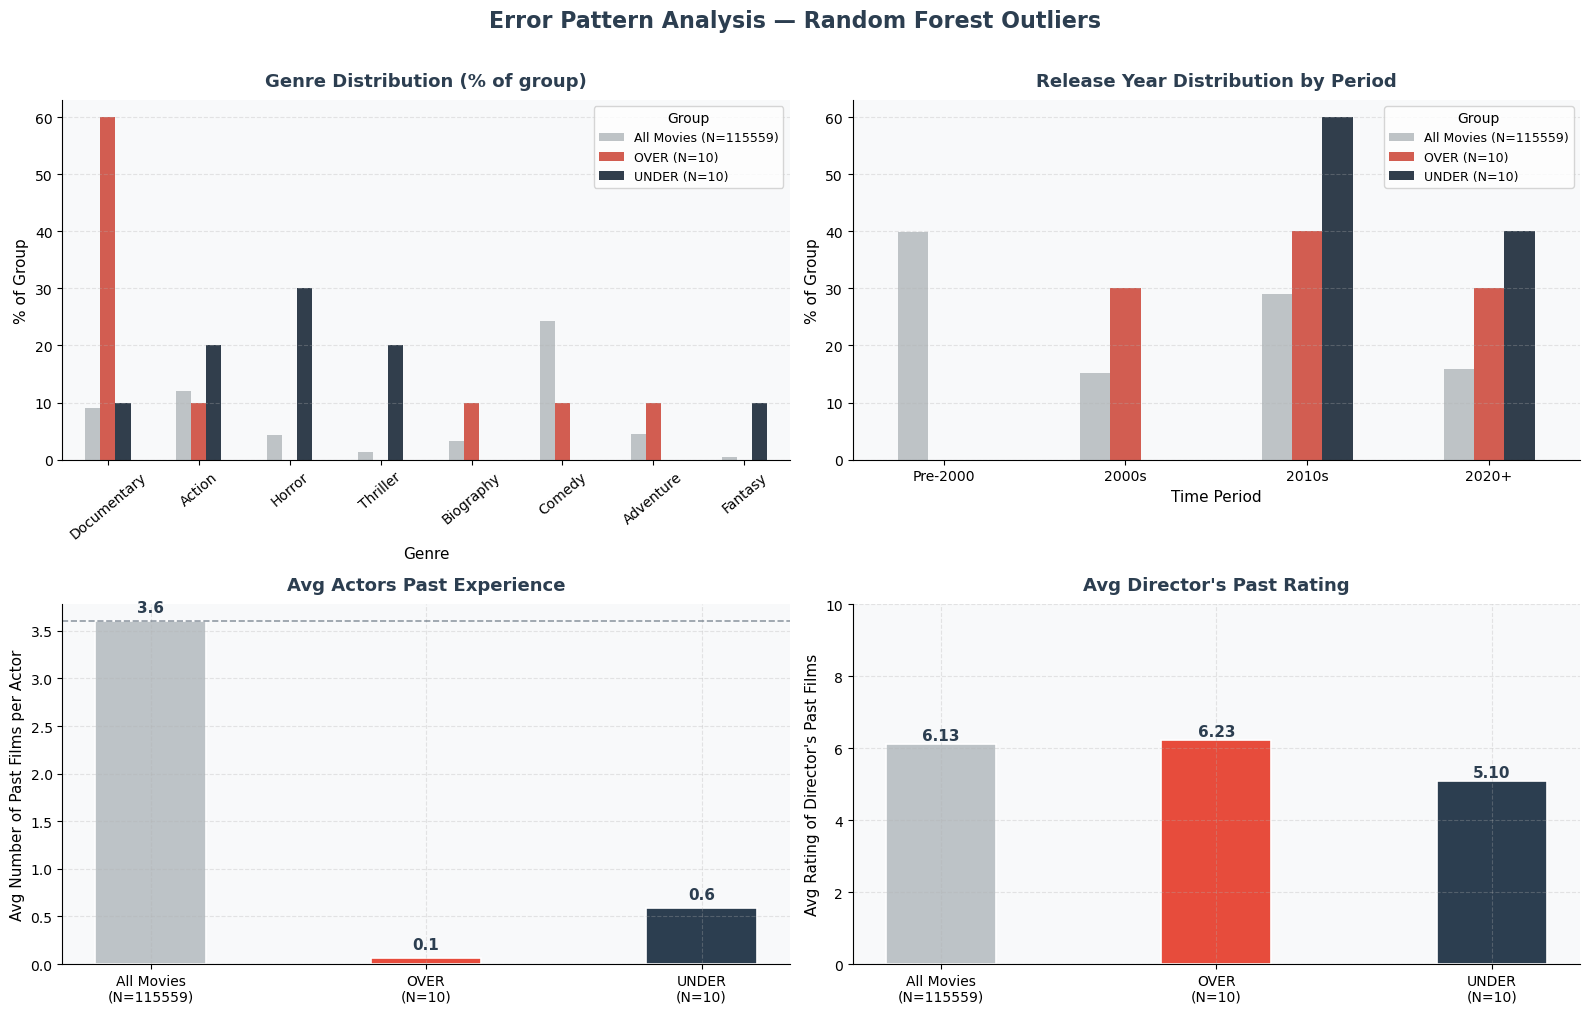

In [27]:
outliers_rf['Error Type'] = outliers_rf['error_rf'].apply(lambda x: 'OVER' if x >= 0 else 'UNDER')
FEAT_COLS    = ['director_past_avg', 'avg_actors_past_exp']
custom_colors = ['#bdc3c7', '#e74c3c', '#2c3e50']
pal = {f'All Movies (N={n_all})': '#bdc3c7',
    f'OVER (N={n_over})':      '#e74c3c',
    f'UNDER (N={n_under})':    '#2c3e50'}
n_all, n_over, n_under = len(errors_df), len(over_rf), len(under_rf)
smart_groups = [f'All Movies\n(N={n_all})', f'OVER\n(N={n_over})', f'UNDER\n(N={n_under})']

all_means  = errors_df[FEAT_COLS].mean()
over_means = over_rf[FEAT_COLS].mean()
under_means= under_rf[FEAT_COLS].mean()

plt.rcParams.update({'font.family': 'sans-serif', 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.3, 'grid.linestyle': '--'})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#ffffff')
fig.suptitle('Error Pattern Analysis — Random Forest Outliers',
             fontsize=16, fontweight='bold', color='#2c3e50', y=1.01)

# [0,0] – Genre Distribution
top_genres = outliers_rf['first_genre'].value_counts().head(8).index.tolist()
rows = []
for genre in top_genres:
    rows += [
        {'Genre': genre, 'Group': f'All Movies (N={n_all})',  'Pct': (errors_df['first_genre'] == genre).mean() * 100},
        {'Genre': genre, 'Group': f'OVER (N={n_over})',       'Pct': (over_rf['first_genre']   == genre).mean() * 100},
        {'Genre': genre, 'Group': f'UNDER (N={n_under})',     'Pct': (under_rf['first_genre']  == genre).mean() * 100},
    ]
sns.barplot(data=pd.DataFrame(rows), x='Genre', y='Pct', hue='Group',
            palette=pal, ax=axes[0, 0], width=0.5)
axes[0, 0].set_title('Genre Distribution (% of group)', fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
axes[0, 0].set_xlabel('Genre', fontsize=11)
axes[0, 0].set_ylabel('% of Group', fontsize=11)
axes[0, 0].tick_params(axis='x', rotation=40)
axes[0, 0].legend(title='Group', fontsize=9)
axes[0, 0].set_facecolor('#f8f9fa')

# [0,1] – Release Year by Period
def year_to_period(y):
    if pd.isna(y): return 'Unknown'
    return 'Pre-2000' if y < 2000 else ('2000s' if y < 2010 else ('2010s' if y < 2020 else '2020+'))

periods = ['Pre-2000', '2000s', '2010s', '2020+']
rows = []
for p in periods:
    rows += [
        {'Period': p, 'Group': f'All Movies (N={n_all})', 'Pct': (errors_df['startYear'].apply(year_to_period) == p).mean() * 100},
        {'Period': p, 'Group': f'OVER (N={n_over})',      'Pct': (over_rf['startYear'].apply(year_to_period)   == p).mean() * 100},
        {'Period': p, 'Group': f'UNDER (N={n_under})',    'Pct': (under_rf['startYear'].apply(year_to_period)  == p).mean() * 100},
    ]
sns.barplot(data=pd.DataFrame(rows), x='Period', y='Pct', hue='Group',
            palette=pal, ax=axes[0, 1], width=0.5)
axes[0, 1].set_title('Release Year Distribution by Period', fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
axes[0, 1].set_xlabel('Time Period', fontsize=11)
axes[0, 1].set_ylabel('% of Group', fontsize=11)
axes[0, 1].legend(title='Group', fontsize=9)
axes[0, 1].set_facecolor('#f8f9fa')

# [1,0] – Avg Actors Past Experience
act_vals = [all_means['avg_actors_past_exp'], over_means['avg_actors_past_exp'], under_means['avg_actors_past_exp']]
bars = axes[1, 0].bar(smart_groups, act_vals, color=custom_colors, edgecolor='white', linewidth=1.2, width=0.4)
axes[1, 0].axhline(all_means['avg_actors_past_exp'], color='#2c3e50', linestyle='--', alpha=0.5, linewidth=1.2)
axes[1, 0].set_title('Avg Actors Past Experience', fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
axes[1, 0].set_ylabel('Avg Number of Past Films per Actor', fontsize=11)
axes[1, 0].set_facecolor('#f8f9fa')
for bar, v in zip(bars, act_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.1f}',
                    ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

# [1,1] – Director Past Avg
avg_vals = [errors_df['director_past_avg'].mean(), over_rf['director_past_avg'].mean(), under_rf['director_past_avg'].mean()]
bars = axes[1, 1].bar(smart_groups, avg_vals, color=custom_colors, edgecolor='white', linewidth=1.2, width=0.4)
axes[1, 1].set_title("Avg Director's Past Rating", fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
axes[1, 1].set_ylabel("Avg Rating of Director's Past Films", fontsize=11)
axes[1, 1].set_ylim(0, 10)
axes[1, 1].set_facecolor('#f8f9fa')
for bar, v in zip(bars, avg_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, v + 0.1, f'{v:.2f}',
                    ha='center', fontsize=11, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

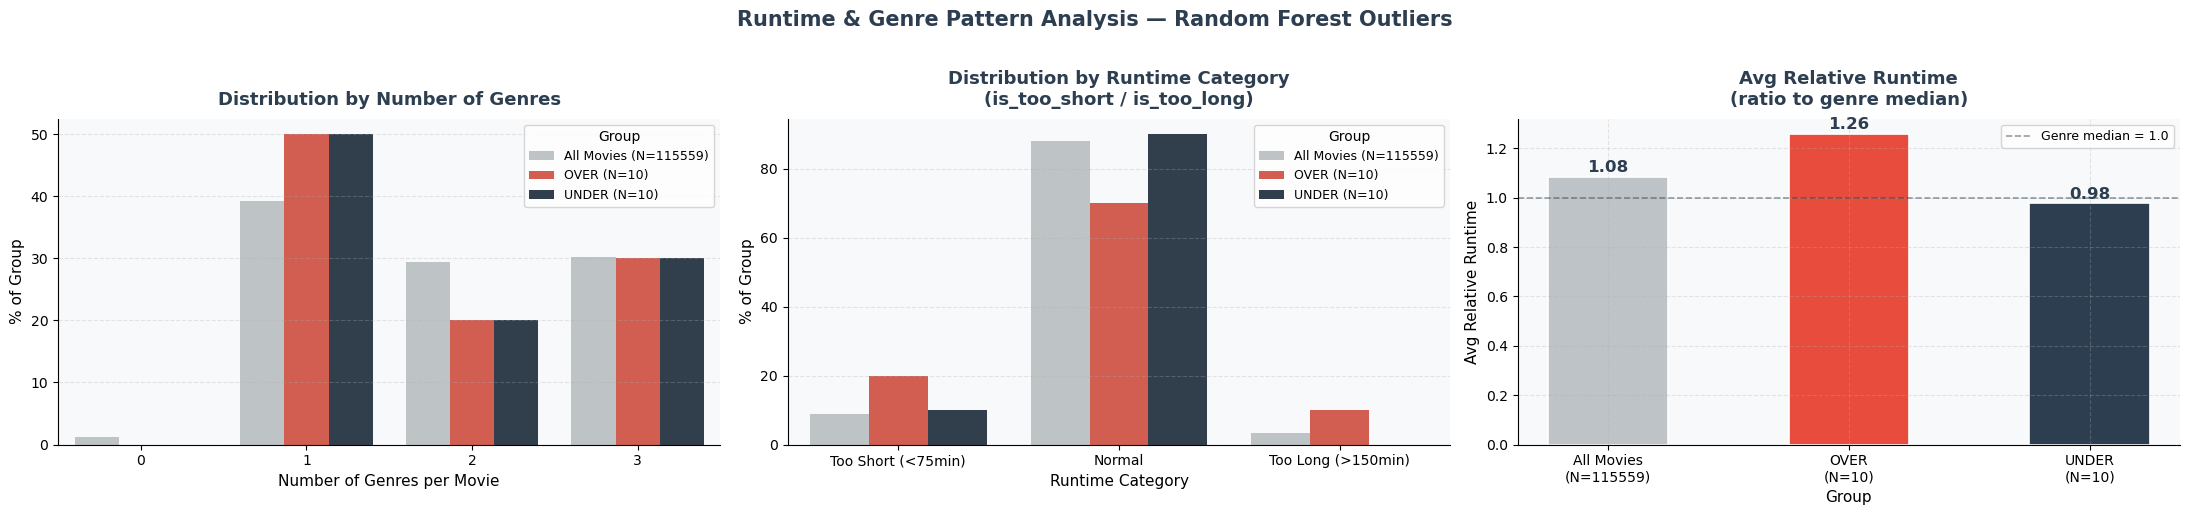

In [28]:
outliers_rf = outliers_rf.copy()
all_rt_cat  = errors_df['runtime_category']

COLORS = ['#bdc3c7', '#e74c3c', '#2c3e50']
pal    = {f'All Movies (N={n_all})': '#bdc3c7',
          f'OVER (N={n_over})':      '#e74c3c',
          f'UNDER (N={n_under})':    '#2c3e50'}

def make_pct_df(categories, all_ser, over_ser, under_ser, col='Category'):
    rows = []
    for cat in categories:
        rows += [
            {col: cat, 'Group': f'All Movies (N={n_all})', 'Pct': (all_ser   == cat).mean() * 100},
            {col: cat, 'Group': f'OVER (N={n_over})',      'Pct': (over_ser  == cat).mean() * 100},
            {col: cat, 'Group': f'UNDER (N={n_under})',    'Pct': (under_ser == cat).mean() * 100},
        ]
    return pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(22, 5))
fig.patch.set_facecolor('#ffffff')
fig.suptitle('Runtime & Genre Pattern Analysis — Random Forest Outliers',
             fontsize=15, fontweight='bold', color='#2c3e50', y=1.02)

# [0] num_genres
ng_cats = sorted(errors_df['num_genres'].unique())
sns.barplot(data=make_pct_df(ng_cats, errors_df['num_genres'],
                             over_rf['num_genres'], under_rf['num_genres'], col='num_genres'),
            x='num_genres', y='Pct', hue='Group', palette=pal, ax=axes[0])
axes[0].set_title('Distribution by Number of Genres', fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
axes[0].set_xlabel('Number of Genres per Movie', fontsize=11)
axes[0].set_ylabel('% of Group', fontsize=11)
axes[0].legend(title='Group', fontsize=9)
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top', 'right']].set_visible(False)

# [1] runtime_category
rt_cats = ['Too Short (<75min)', 'Normal', 'Too Long (>150min)']
sns.barplot(data=make_pct_df(rt_cats, all_rt_cat,
                             outliers_rf.loc[over_rf.index,  'runtime_category'],
                             outliers_rf.loc[under_rf.index, 'runtime_category']),
            x='Category', y='Pct', hue='Group', palette=pal, ax=axes[1])
axes[1].set_title('Distribution by Runtime Category\n(is_too_short / is_too_long)', fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
axes[1].set_xlabel('Runtime Category', fontsize=11)
axes[1].set_ylabel('% of Group', fontsize=11)
axes[1].legend(title='Group', fontsize=9)
axes[1].set_facecolor('#f8f9fa')
axes[1].spines[['top', 'right']].set_visible(False)

# [2] relative runtime
rrt_vals   = [errors_df['relative_runtime_by_genre'].mean(),
              outliers_rf.loc[over_rf.index,  'relative_runtime_by_genre'].mean(),
              outliers_rf.loc[under_rf.index, 'relative_runtime_by_genre'].mean()]
bar_labels = [f'All Movies\n(N={n_all})', f'OVER\n(N={n_over})', f'UNDER\n(N={n_under})']
bars = axes[2].bar(bar_labels, rrt_vals, color=COLORS, edgecolor='white', linewidth=1.2, width=0.5)
axes[2].axhline(1.0, color='#2c3e50', linestyle='--', alpha=0.5, linewidth=1.2, label='Genre median = 1.0')
axes[2].set_title('Avg Relative Runtime\n(ratio to genre median)', fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
axes[2].set_xlabel('Group', fontsize=11)
axes[2].set_ylabel('Avg Relative Runtime', fontsize=11)
axes[2].legend(fontsize=9)
axes[2].set_facecolor('#f8f9fa')
axes[2].spines[['top', 'right']].set_visible(False)
for bar, v in zip(bars, rrt_vals):
    if not np.isnan(v):
        axes[2].text(bar.get_x() + bar.get_width()/2, v + 0.02, f'{v:.2f}',
                     ha='center', fontsize=12, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

In [31]:
# השוואה בין המודלים
overlap_idx = outliers_rf.index.intersection(outliers_en.index)
only_rf     = outliers_rf.index.difference(outliers_en.index)
only_en     = outliers_en.index.difference(outliers_rf.index)

display(HTML(f"""
    <div style="margin:16px 0; padding:14px 20px; border-left:5px solid #2c3e50;
                background:#f8f9fa; font-family:sans-serif; border-radius:4px;">
        <div style="font-size:15px; font-weight:bold; color:#2c3e50; margin-bottom:8px;">
        Comparing outliers between models
</div>
        <table style="border-collapse:collapse; font-size:13px;">
            <tr>
                <td style="padding:3px 20px 3px 0; color:#555;">Joint films (both models)</td>
                <td style="font-weight:bold; color:#2c3e50;">{len(overlap_idx)} / 20</td>
            </tr>
            <tr>
                <td style="padding:3px 20px 3px 0; color:#555;">Unique to Random Forest</td>
                <td style="font-weight:bold; color:#2c3e50;">{len(only_rf)}</td>
            </tr>
            <tr>
                <td style="padding:3px 20px 3px 0; color:#555;">Unique to Elastic Net</td>
                <td style="font-weight:bold; color:#2c3e50;">{len(only_en)}</td>
            </tr>
        </table>
    </div>
"""))

if len(overlap_idx) > 0:
    COLS_OVERLAP = ['primaryTitle', 'y_true', 'pred_rf', 'pred_en', 'error_rf', 'error_en']
    show_titled_table(
        errors_df.loc[overlap_idx],
        "Movies that appear as outliers in both models",
        COLS_OVERLAP,
        highlight_col='error_rf',
        higher_is_better=False
    )

Joint films (both models),9 / 20
Unique to Random Forest,11
Unique to Elastic Net,11


,primaryTitle,y_true,pred_rf,pred_en,error_rf,error_en
1,Justin Bieber: Always Believing,1.00,7.19,6.85,6.19,5.85
2,Rape of the Soul,1.70,7.75,7.39,6.05,5.69
3,Kurz,1.20,7.09,7.14,5.89,5.94
4,Obama in NC: The Path to History,1.50,7.29,7.15,5.79,5.65
5,Ramo Trip,1.40,7.19,7.22,5.79,5.82
6,Vixen Highway 2006: It Came from Uranus!,1.20,6.69,7.36,5.49,6.16
7,One Direction: I Love One Direction,9.20,4.48,4.90,-4.72,-4.30
8,Hantu Nan Sempit,8.70,4.07,3.92,-4.63,-4.78
9,Long Shot Louie,8.10,3.57,3.23,-4.53,-4.87


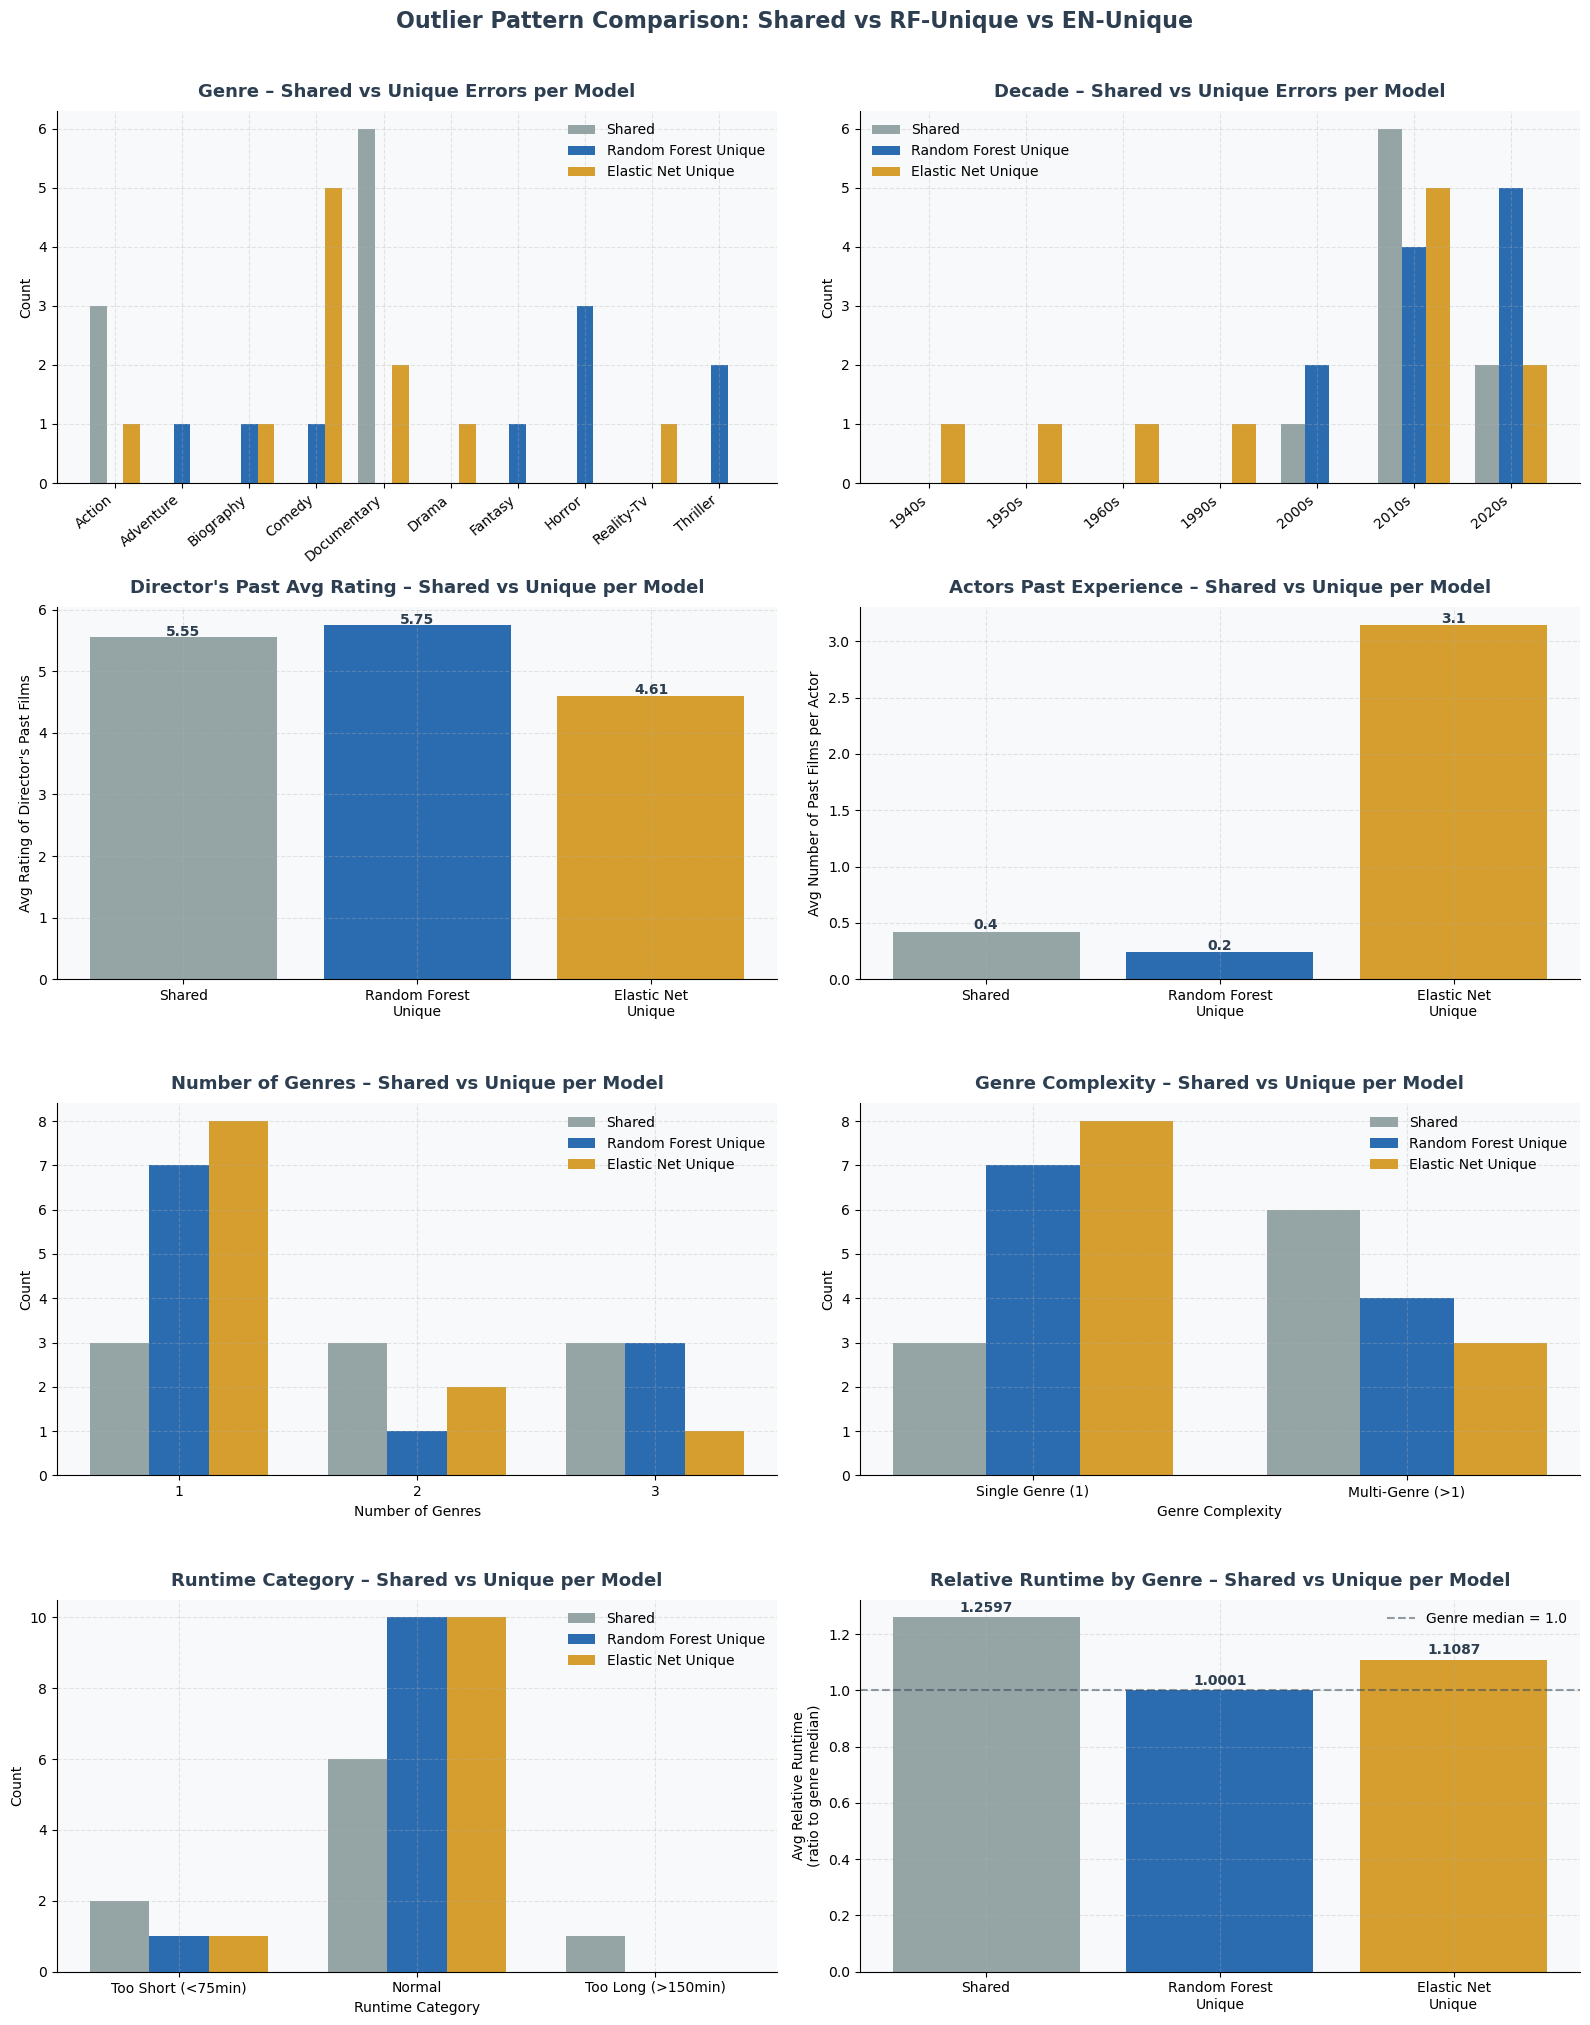

In [50]:
best_name  = "Random Forest"
other_name = "Elastic Net"

only_best  = outliers_rf.index.difference(outliers_en.index)
only_other = outliers_en.index.difference(outliers_rf.index)

sub_best   = errors_df.loc[only_best]
sub_other  = errors_df.loc[only_other]
sub_shared = errors_df.loc[overlap_idx]

groups = ['Shared', f'{best_name}\nUnique', f'{other_name}\nUnique']
colors = ['#95a5a6', '#2B6CB0', '#D69E2E']   
w = 0.25

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
fig.patch.set_facecolor('#ffffff')
fig.suptitle('Outlier Pattern Comparison: Shared vs RF-Unique vs EN-Unique',
             fontsize=16, fontweight='bold', color='#2c3e50', y=1.01)

# ── helper לעיצוב אחיד ──
def _style(ax, title):
    ax.set_title(title, fontsize=13, fontweight='bold', color='#2c3e50', pad=10)
    ax.set_facecolor('#f8f9fa')
    ax.spines[['top', 'right']].set_visible(False)

# [0,0] – ז'אנר
genre_shared = sub_shared['first_genre'].value_counts().head(6)
genre_best   = sub_best['first_genre'].value_counts().head(6)
genre_other  = sub_other['first_genre'].value_counts().head(6)
all_genres   = sorted(set(genre_shared.index) | set(genre_best.index) | set(genre_other.index))
x = range(len(all_genres))
axes[0, 0].bar([i - w for i in x], [genre_shared.get(g, 0) for g in all_genres], w, label='Shared',              color='#95a5a6')
axes[0, 0].bar([i     for i in x], [genre_best.get(g, 0)   for g in all_genres], w, label=f'{best_name} Unique', color='#2B6CB0')
axes[0, 0].bar([i + w for i in x], [genre_other.get(g, 0)  for g in all_genres], w, label=f'{other_name} Unique',color='#D69E2E')
axes[0, 0].set_xticks(list(x))
axes[0, 0].set_xticklabels(all_genres, rotation=40, ha='right')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(frameon=False)
_style(axes[0, 0], 'Genre – Shared vs Unique Errors per Model')

# [0,1] – עשור
dec_shared = (sub_shared['startYear'] // 10 * 10).value_counts().sort_index()
dec_best   = (sub_best['startYear']   // 10 * 10).value_counts().sort_index()
dec_other  = (sub_other['startYear']  // 10 * 10).value_counts().sort_index()
all_dec    = sorted(set(dec_shared.index) | set(dec_best.index) | set(dec_other.index))
dec_labels = [f"{int(d)}s" for d in all_dec]
x = range(len(all_dec))
axes[0, 1].bar([i - w for i in x], [dec_shared.get(d, 0) for d in all_dec], w, label='Shared',              color='#95a5a6')
axes[0, 1].bar([i     for i in x], [dec_best.get(d, 0)   for d in all_dec], w, label=f'{best_name} Unique', color='#2B6CB0')
axes[0, 1].bar([i + w for i in x], [dec_other.get(d, 0)  for d in all_dec], w, label=f'{other_name} Unique',color='#D69E2E')
axes[0, 1].set_xticks(list(x))
axes[0, 1].set_xticklabels(dec_labels, rotation=40, ha='right')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(frameon=False)
_style(axes[0, 1], 'Decade – Shared vs Unique Errors per Model')

# [1,0] – Director Past Avg
dir_v = [sub_shared['director_past_avg'].mean(),
         sub_best['director_past_avg'].mean(),
         sub_other['director_past_avg'].mean()]
bars = axes[1, 0].bar(groups, dir_v, color=colors)
axes[1, 0].set_ylabel("Avg Rating of Director's Past Films")
for bar, v in zip(bars, dir_v):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2,
                    v + 0.02, f'{v:.2f}', ha='center', fontweight='bold', color='#2c3e50')
_style(axes[1, 0], "Director's Past Avg Rating – Shared vs Unique per Model")

# [1,1] – Actors Past Experience
act_v = [sub_shared['avg_actors_past_exp'].mean(),
         sub_best['avg_actors_past_exp'].mean(),
         sub_other['avg_actors_past_exp'].mean()]
bars = axes[1, 1].bar(groups, act_v, color=colors)
axes[1, 1].set_ylabel('Avg Number of Past Films per Actor')
for bar, v in zip(bars, act_v):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    v + 0.02, f'{v:.1f}', ha='center', fontweight='bold', color='#2c3e50')
_style(axes[1, 1], 'Actors Past Experience – Shared vs Unique per Model')

# [2,0] – מספר ז'אנרים
num_genres_shared = sub_shared['num_genres'].value_counts().sort_index()
num_genres_best   = sub_best['num_genres'].value_counts().sort_index()
num_genres_other  = sub_other['num_genres'].value_counts().sort_index()
all_nums          = sorted(set(num_genres_shared.index) | set(num_genres_best.index) | set(num_genres_other.index))
x_nums            = range(len(all_nums))
axes[2, 0].bar([i - w for i in x_nums], [num_genres_shared.get(n, 0) for n in all_nums], w, label='Shared',              color='#95a5a6')
axes[2, 0].bar([i     for i in x_nums], [num_genres_best.get(n, 0)   for n in all_nums], w, label=f'{best_name} Unique', color='#2B6CB0')
axes[2, 0].bar([i + w for i in x_nums], [num_genres_other.get(n, 0)  for n in all_nums], w, label=f'{other_name} Unique',color='#D69E2E')
axes[2, 0].set_xticks(list(x_nums))
axes[2, 0].set_xticklabels([str(n) for n in all_nums])
axes[2, 0].set_ylabel('Count')
axes[2, 0].set_xlabel('Number of Genres')
axes[2, 0].legend(frameon=False)
_style(axes[2, 0], 'Number of Genres – Shared vs Unique per Model')

# [2,1] – מורכבות ז'אנר
comp_shared = sub_shared['num_genres'].apply(lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
comp_best   = sub_best['num_genres'].apply(  lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
comp_other  = sub_other['num_genres'].apply( lambda x: 'Single Genre (1)' if x == 1 else 'Multi-Genre (>1)').value_counts()
all_comps   = ['Single Genre (1)', 'Multi-Genre (>1)']
x_comps     = range(len(all_comps))
axes[2, 1].bar([i - w for i in x_comps], [comp_shared.get(c, 0) for c in all_comps], w, label='Shared',              color='#95a5a6')
axes[2, 1].bar([i     for i in x_comps], [comp_best.get(c, 0)   for c in all_comps], w, label=f'{best_name} Unique', color='#2B6CB0')
axes[2, 1].bar([i + w for i in x_comps], [comp_other.get(c, 0)  for c in all_comps], w, label=f'{other_name} Unique',color='#D69E2E')
axes[2, 1].set_xticks(list(x_comps))
axes[2, 1].set_xticklabels(all_comps)
axes[2, 1].set_ylabel('Count')
axes[2, 1].set_xlabel('Genre Complexity')
axes[2, 1].legend(frameon=False)
_style(axes[2, 1], 'Genre Complexity – Shared vs Unique per Model')

# [3,0] – Runtime Category
def _runtime_counts(sub_df):
    return sub_df['runtime_category'].value_counts()

rt_cats = ['Too Short (<75min)', 'Normal', 'Too Long (>150min)']
rt_shared = _runtime_counts(sub_shared)
rt_best   = _runtime_counts(sub_best)
rt_other  = _runtime_counts(sub_other)
x_rt      = range(len(rt_cats))
axes[3, 0].bar([i - w for i in x_rt], [rt_shared.get(c, 0) for c in rt_cats], w, label='Shared',              color='#95a5a6')
axes[3, 0].bar([i     for i in x_rt], [rt_best.get(c, 0)   for c in rt_cats], w, label=f'{best_name} Unique', color='#2B6CB0')
axes[3, 0].bar([i + w for i in x_rt], [rt_other.get(c, 0)  for c in rt_cats], w, label=f'{other_name} Unique',color='#D69E2E')
axes[3, 0].set_xticks(list(x_rt))
axes[3, 0].set_xticklabels(rt_cats)
axes[3, 0].set_ylabel('Count')
axes[3, 0].set_xlabel('Runtime Category')
axes[3, 0].legend(frameon=False)
_style(axes[3, 0], 'Runtime Category – Shared vs Unique per Model')

# [3,1] – Relative Runtime
rrt_v = [sub_shared['relative_runtime_by_genre'].mean(),
         sub_best['relative_runtime_by_genre'].mean(),
         sub_other['relative_runtime_by_genre'].mean()]
bars = axes[3, 1].bar(groups, rrt_v, color=colors)
axes[3, 1].set_ylabel('Avg Relative Runtime\n(ratio to genre median)')
axes[3, 1].axhline(1.0, color='#2c3e50', linestyle='--', alpha=0.5, label='Genre median = 1.0')
axes[3, 1].legend(frameon=False)
for bar, v in zip(bars, rrt_v):
    if not np.isnan(v):
        axes[3, 1].text(bar.get_x() + bar.get_width()/2,
                        v + 0.02, f'{v:.4f}', ha='center', fontweight='bold', color='#2c3e50')
_style(axes[3, 1], 'Relative Runtime by Genre – Shared vs Unique per Model')

plt.tight_layout()
plt.show()

# הערה לעינב 
הגרף האפור זה הנתונים מהסרטים המשותפים של שני המודלים (בטעויות) ואז כתום זה של הרנדום וכחול זה של האלסטיק 
עשיתי את זה ככה כי הוא רצה לראות מה ההבדלךים בין המודלים ומה השגיאה הייחודית של כול מודל ולכן חייב את השגיאות המשותפות גם 

## ניתוח הוגנות (Fairness Analysis)

In [42]:
fairness_df = errors_df.copy()
fairness_df['decade'] = (fairness_df['startYear'] // 10 * 10).astype('Int64')
overall_rmse = np.sqrt(mean_squared_error(fairness_df['y_true'], fairness_df['pred_rf']))
overall_mae  = mean_absolute_error(fairness_df['y_true'], fairness_df['pred_rf'])
def slice_metrics(df, label):
    rmse = np.sqrt(mean_squared_error(df['y_true'], df['pred_rf']))
    mae  = mean_absolute_error(df['y_true'], df['pred_rf'])
    
    # חישוב פערי האחוזים משני המדדים
    pct_rmse = (rmse / overall_rmse - 1) * 100
    pct_mae  = (mae / overall_mae - 1) * 100
    
    return {
        'Slice': label, 
        'N': len(df),
        'RMSE': round(rmse, 4), 
        'MAE': round(mae, 4),
        'RMSE vs overall': f'{pct_rmse:+.1f}%',
        'MAE vs overall': f'{pct_mae:+.1f}%' }

In [43]:
# By Genre (top 5, multi-label)
genre_rows = []
for _, row in fairness_df.iterrows():
    for g in (row['genres'] if isinstance(row['genres'], list) else []):
        genre_rows.append(row.to_dict() | {'genre_label': g})
genre_long  = pd.DataFrame(genre_rows)
top5_genres = genre_long['genre_label'].value_counts().head(5).index
genre_df = pd.DataFrame([
    slice_metrics(genre_long[genre_long['genre_label'] == g], g)
    for g in top5_genres])

,Slice,N,RMSE,MAE,RMSE vs overall,MAE vs overall
0,Drama,58460,1.024300,0.780100,-5.4%,-5.1%
1,Comedy,33316,1.089500,0.830000,+0.6%,+0.9%
2,Romance,15693,0.983800,0.748000,-9.2%,-9.0%
3,Action,13987,1.159900,0.890100,+7.1%,+8.2%
4,Documentary,13014,1.025200,0.764400,-5.3%,-7.0%


,Slice,N,RMSE,MAE,RMSE vs overall,MAE vs overall
0,1984,970,0.958500,0.746100,-11.5%,-9.3%
1,1994,930,1.002700,0.770800,-7.4%,-6.3%
2,2004,1604,1.128500,0.864900,+4.2%,+5.2%
3,2014,3366,1.146700,0.879100,+5.9%,+6.9%
4,2024,3844,1.241100,0.955400,+14.6%,+16.2%


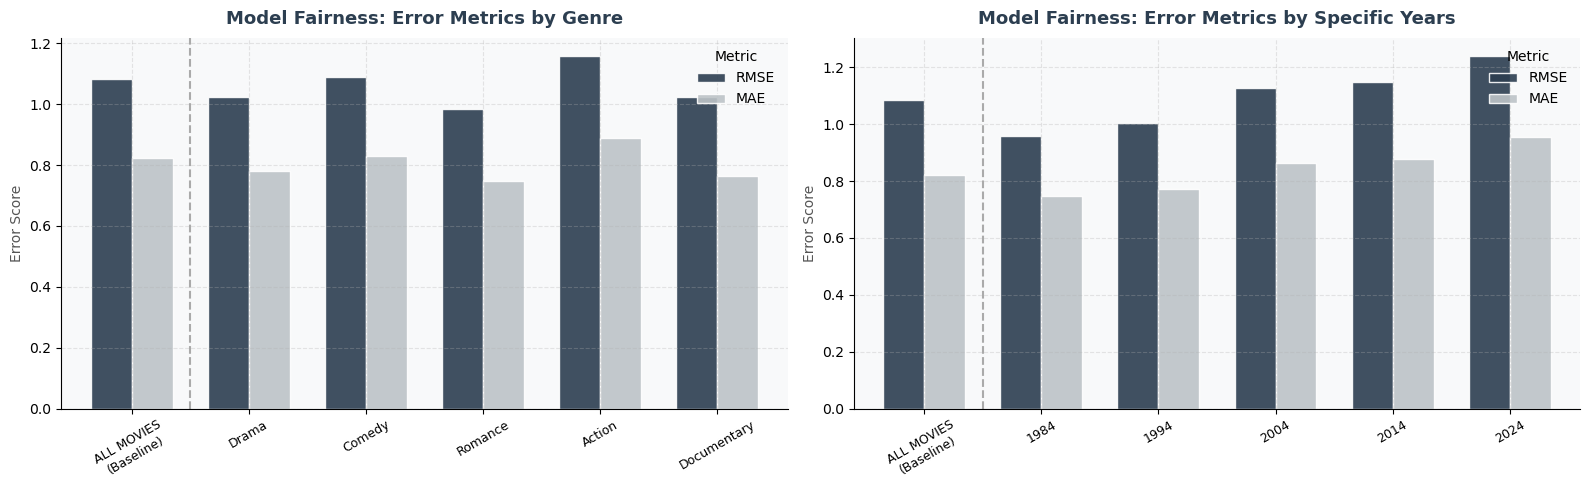

In [44]:
target_years = [1984, 1994, 2004, 2014, 2024]
decade_df = pd.DataFrame([
    slice_metrics(fairness_df[fairness_df['startYear'] == year], f"{year}")
    for year in target_years
    if len(fairness_df[fairness_df['startYear'] == year]) > 0
])

# ── טבלאות מעוצבות ──
display(HTML("""
    <div style="margin: 16px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            Error by Genre (Top 5)
        </span>
    </div>
"""))
display(style_table(genre_df.reset_index(drop=True), highlight_col='RMSE', higher_is_better=False))

display(HTML("""
    <div style="margin: 24px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            Error by Specific Years
        </span>
    </div>
"""))
display(style_table(decade_df.reset_index(drop=True), highlight_col='RMSE', higher_is_better=False))

# ── גרפים ──
overall_row = pd.DataFrame([{
    'Slice': 'ALL MOVIES\n(Baseline)',
    'RMSE': overall_rmse,
    'MAE': overall_mae}])

plot_genre_df  = pd.concat([overall_row, genre_df],  ignore_index=True)
plot_decade_df = pd.concat([overall_row, decade_df], ignore_index=True)

RMSE_CLR = '#2c3e50'
MAE_CLR  = '#bdc3c7'

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor('#ffffff')

plot_genre_df.set_index('Slice')[['RMSE', 'MAE']].plot(
    kind='bar', ax=axes[0], color=[RMSE_CLR, MAE_CLR],
    width=0.7, edgecolor='white', alpha=0.9)
axes[0].set_ylabel('Error Score', color='#555')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
axes[0].legend(title='Metric', frameon=False)
axes[0].axvline(0.5, color='#aaa', linestyle='--', linewidth=1.5)
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_title('Model Fairness: Error Metrics by Genre',
                  fontsize=13, fontweight='bold', color='#2c3e50', pad=10)

plot_decade_df.set_index('Slice')[['RMSE', 'MAE']].plot(
    kind='bar', ax=axes[1], color=[RMSE_CLR, MAE_CLR],
    width=0.7, edgecolor='white', alpha=0.9)
axes[1].set_ylabel('Error Score', color='#555')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30, labelsize=9)
axes[1].legend(title='Metric', frameon=False)
axes[1].axvline(0.5, color='#aaa', linestyle='--', linewidth=1.5)
axes[1].set_facecolor('#f8f9fa')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_title('Model Fairness: Error Metrics by Specific Years',
                  fontsize=13, fontweight='bold', color='#2c3e50', pad=10)

plt.tight_layout()
plt.show()

,Feature,EN_coef
0,director_genre_past_avg,0.421200
1,relative_runtime_by_genre,0.210100
2,director_past_avg,0.163300
3,is_new_actors,0.131200
4,is_too_short,0.074000


,Feature,RF_importance
0,director_genre_past_avg,0.565100
1,director_past_avg,0.141400
2,relative_runtime_by_genre,0.128200
3,startYear,0.044000
4,avg_actors_past_experience,0.039100


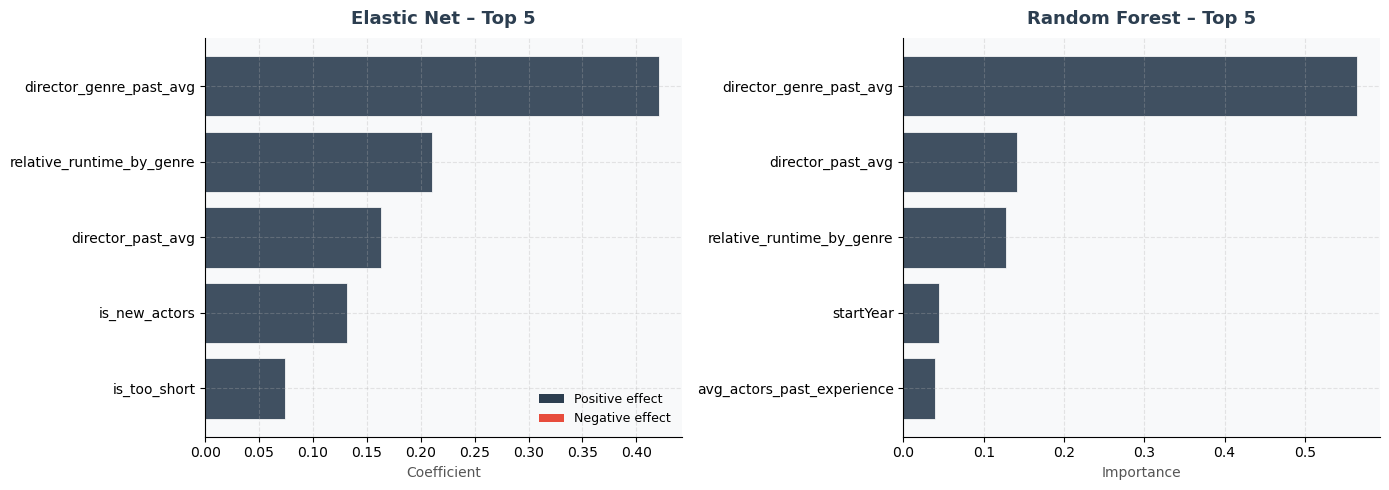

In [47]:
en_coefs = pipeline_en['model'].best_estimator_.coef_
rf_importances = pipeline_rf['model'].best_estimator_.feature_importances_

feat_df = pd.DataFrame({
    'Feature':       FEATURE_COLS,
    'EN_coef':       en_coefs,
    'RF_importance': rf_importances,
})
# top-5 לפי כל מודל בנפרד
top5_en = feat_df.reindex(feat_df['EN_coef'].abs().sort_values(ascending=False).index).head(5)
top5_rf = feat_df.sort_values('RF_importance', ascending=False).head(5)

# ── טבלאות ──
display(HTML("""
    <div style="margin: 16px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            Elastic Net – Top 5 Features
        </span>
    </div>
"""))
display(style_table(top5_en[['Feature', 'EN_coef']].round(4).reset_index(drop=True)))

display(HTML("""
    <div style="margin: 24px 0 6px 0;">
        <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                     border-radius:4px; font-family:sans-serif;
                     font-size:14px; font-weight:bold;">
            Random Forest – Top 5 Features
        </span>
    </div>
"""))
display(style_table(top5_rf[['Feature', 'RF_importance']].round(4).reset_index(drop=True)))

# ── גרפים ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#ffffff')

# Elastic Net — חיובי/שלילי בצבעים שונים
en_sorted  = top5_en.set_index('Feature')['EN_coef'].sort_values()
colors_en  = ['#e74c3c' if c < 0 else '#2c3e50' for c in en_sorted]
axes[0].barh(range(len(en_sorted)), en_sorted.values,
             color=colors_en, edgecolor='white', linewidth=0.6, alpha=0.9)
axes[0].set_yticks(range(len(en_sorted)))
axes[0].set_yticklabels(en_sorted.index, fontsize=10)
axes[0].axvline(0, color='#2c3e50', linewidth=1.2)
axes[0].set_xlabel('Coefficient', color='#555')
axes[0].set_facecolor('#f8f9fa')
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].set_title('Elastic Net – Top 5', fontsize=13,
                  fontweight='bold', color='#2c3e50', pad=10)

# legend ידני לכיוון ההשפעה
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(fc='#2c3e50', label='Positive effect'),
                         Patch(fc='#e74c3c', label='Negative effect')],
               frameon=False, fontsize=9)

# Random Forest — importance (חיובי תמיד)
rf_sorted = top5_rf.set_index('Feature')['RF_importance'].sort_values()
axes[1].barh(range(len(rf_sorted)), rf_sorted.values,
             color='#2c3e50', edgecolor='white', linewidth=0.6, alpha=0.9)
axes[1].set_yticks(range(len(rf_sorted)))
axes[1].set_yticklabels(rf_sorted.index, fontsize=10)
axes[1].set_xlabel('Importance', color='#555')
axes[1].set_facecolor('#f8f9fa')
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].set_title('Random Forest – Top 5', fontsize=13,
                  fontweight='bold', color='#2c3e50', pad=10)

plt.tight_layout()
plt.show()

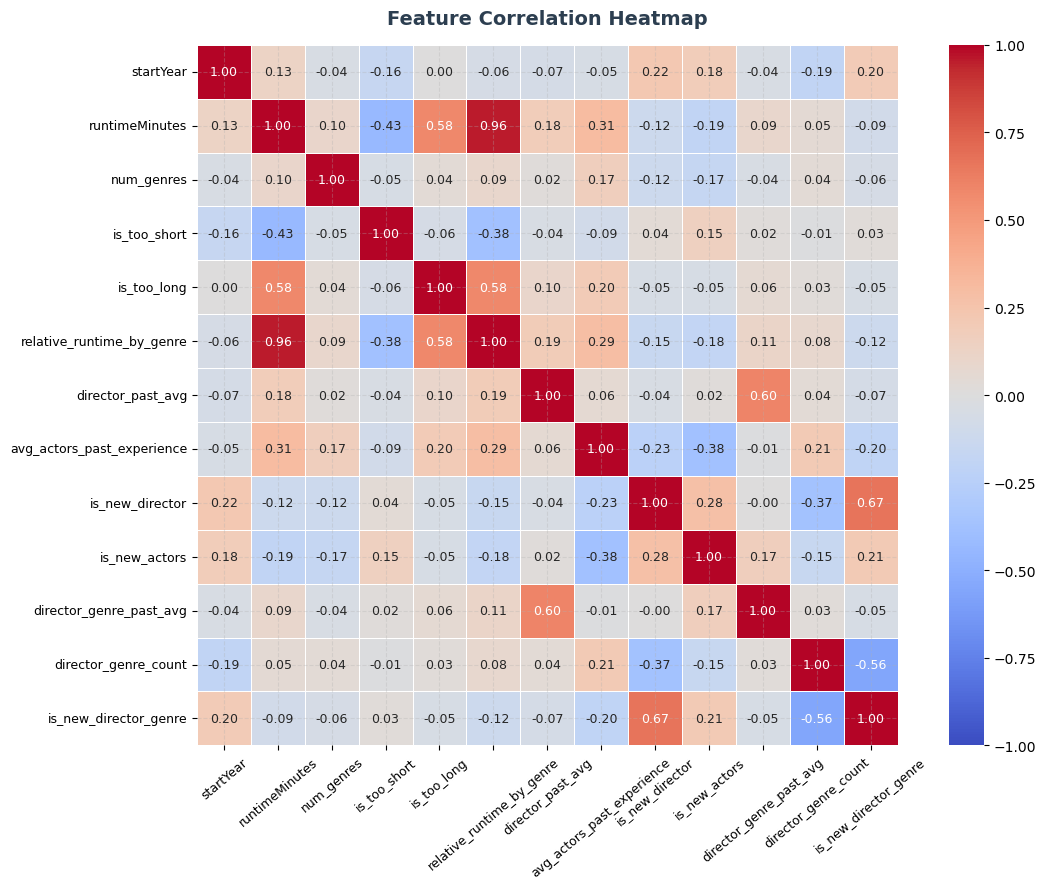

,Feature 1,Feature 2,Correlation
0,runtimeMinutes,relative_runtime_by_genre,0.960000


In [52]:
# ── Correlation Heatmap between Features ──
import seaborn as sns

# חישוב מטריצת קורלציה על הפיצ'רים המעובדים
X_engineered = feature_engineering_pipeline.fit_transform(X, y)
corr_cols = [c for c in FEATURE_COLS if c in X_engineered.columns]
corr_matrix = X_engineered[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor('#ffffff')

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    ax=ax,
    annot_kws={'size': 9},
)

ax.set_title('Feature Correlation Heatmap',
             fontsize=14, fontweight='bold', color='#2c3e50', pad=15)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.show()

# הדגשת זוגות עם קורלציה גבוהה (מעל 0.7 בערך מוחלט)
high_corr = []
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            high_corr.append({
                'Feature 1': corr_matrix.index[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': val
            })

if high_corr:
    display(HTML("""
        <div style="margin:16px 0 6px 0;">
            <span style="background-color:#2c3e50; color:white; padding:6px 16px;
                         border-radius:4px; font-family:sans-serif;
                         font-size:14px; font-weight:bold;">
                זוגות עם קורלציה גבוהה (|r| > 0.7)
            </span>
        </div>
    """))
    display(style_table(pd.DataFrame(high_corr), highlight_col='Correlation', higher_is_better=False))
else:
    print("אין זוגות עם קורלציה מעל 0.7 — הפיצ'רים עצמאיים מספיק.")

## 12. שמירת מודל סופי + prepare_data

### prepare_data

מקבלת רק את דאטת התחרות.
ניגשת ל-`df_train_global` שנשמר בזיכרון ה-notebook –
כך הפיצ'רים ההיסטוריים מחושבים על בסיס דאטת האימון.

<div dir="rtl">
כדי שבזמן הגנת הפרויקט הוא יוכל לטעון אותו בשנייה אחת ולבחון אותו על סרטים חדשים, בלי לחכות שהקוד יתאמן מחדש
הקוד הזה ייצור לך קובץ בשם model.pkl בתיקייה, ואותו את מעלה לגיטהאב.
</div>

In [ ]:
#  אימון סופי על כל הדאטה כדי שהמודל יכיל את כל המידע ויגיע למקסימום דיוק
pipeline_rf.fit(X, y)
# 2. שמירת ה-Pipeline המלא (כולל הטרנספורמרים החכמים והמודל הסופי המאומן!)
joblib.dump(pipeline_rf, 'model.pkl')

print(" ה-Pipeline המוביל אומן על כל הנתונים ונשמר בהצלחה כ-model.pkl!")